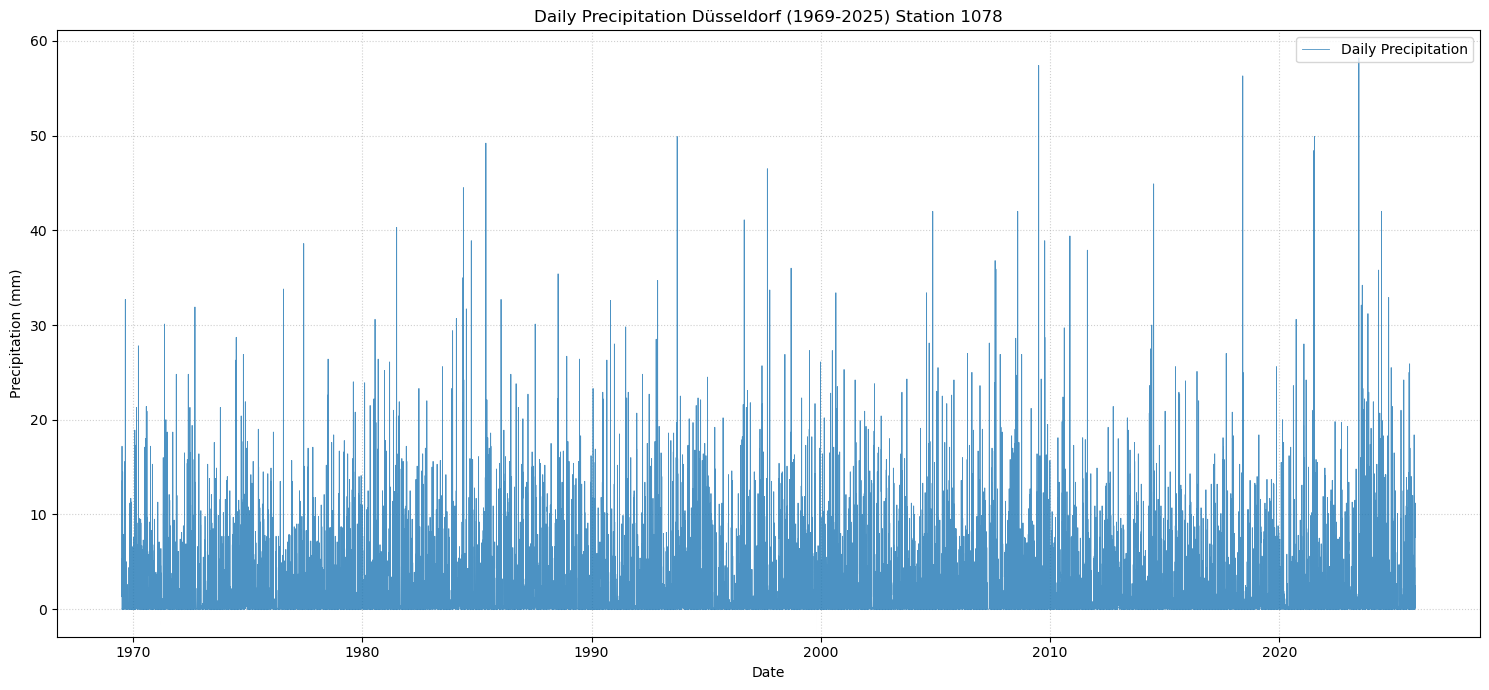

In [1]:
import pandas as pd
import matplotlib.pyplot as plt

# --- Configuration ---
# Update this path if your file is located elsewhere!
file_name = 'data/dusseldorf_precipitation.csv'

# Column names to look for (based on your CSV header)
date_col_name = 'Zeitstempel'
value_col_name = 'Wert'
# --- End Configuration ---

# 1. Read file as raw text lines
# This approach is chosen because the CSV has a complex quoting format 
# (double quotes around lines AND values) which confuses the standard pandas parser.
with open(file_name, 'r') as f:
    lines = f.readlines()

# 2. Parse data manually
data = []
for line in lines:
    line = line.strip()
    
    # Remove outer quotes if present
    if line.startswith('"'): line = line[1:]
    if line.endswith('"'): line = line[:-1]
    
    # Clean up inner quotes (DWD format often uses "" as escape or separator)
    # We replace double quotes with nothing, and single quotes with nothing
    # Then split by comma.
    clean_line = line.replace('""', '').replace('"', '')
    
    # Split the line into columns
    parts = clean_line.split(',')
    
    # Remove empty strings that might appear at the end (due to trailing commas)
    parts = [p for p in parts if p.strip() != '']
    
    data.append(parts)

# 3. Create DataFrame
# The first row contains headers
if not data:
    raise ValueError("File appears to be empty.")
    
header = [h.strip() for h in data[0]]
rows = data[1:]

df = pd.DataFrame(rows, columns=header)

# 4. Validate and Find Columns
# Sometimes column names have extra spaces, so we search for them flexibly
if date_col_name not in df.columns:
    found = False
    for col in df.columns:
        if date_col_name in col:
            date_col_name = col
            found = True
            break
    if not found:
        raise ValueError(f"Column '{date_col_name}' not found. Available: {df.columns}")

if value_col_name not in df.columns:
    for col in df.columns:
        if value_col_name in col:
            value_col_name = col
            break

# 5. Data Conversion and Cleaning
# Convert date string to datetime objects
df[date_col_name] = pd.to_datetime(df[date_col_name], format='%Y-%m-%d', errors='coerce')

# Convert values to numeric (floats)
df[value_col_name] = pd.to_numeric(df[value_col_name], errors='coerce')

# Drop rows where date or value conversion failed
df.dropna(subset=[date_col_name, value_col_name], inplace=True)

# Set date as index
df.set_index(date_col_name, inplace=True)

# Filter out invalid negative values (precipitation cannot be negative)
df = df[df[value_col_name] >= 0]

# Ensure the timeline is continuous (fill missing days with 0.0)
df = df.asfreq('D', fill_value=0.0)

# 6. Plotting Daily Data
plt.figure(figsize=(15, 7))

# Plot daily values
plt.plot(df.index, df[value_col_name], 
         label='Daily Precipitation', 
         color='#1f77b4',  # Standard matplotlib blue
         linewidth=0.6,    # Thinner line for dense daily data
         alpha=0.8)        # Slight transparency

# Setup titles and labels
start_year = df.index.min().year
end_year = df.index.max().year

plt.title(f'Daily Precipitation Düsseldorf ({start_year}-{end_year}) Station 1078')
plt.xlabel('Date')
plt.ylabel('Precipitation (mm)')

# Add a legend and grid
plt.legend(loc='upper right')
plt.grid(True, linestyle=':', alpha=0.6)

# Optional: Set Y-axis limit if outliers make the plot unreadable
# plt.ylim(0, 100) 

plt.tight_layout()

# # 7. Save and Show
# output_filename = 'dusseldorf_precipitation_daily.png'
# plt.savefig(output_filename, dpi=150)
# print(f"Success! Plot saved as: {output_filename}")
plt.show()

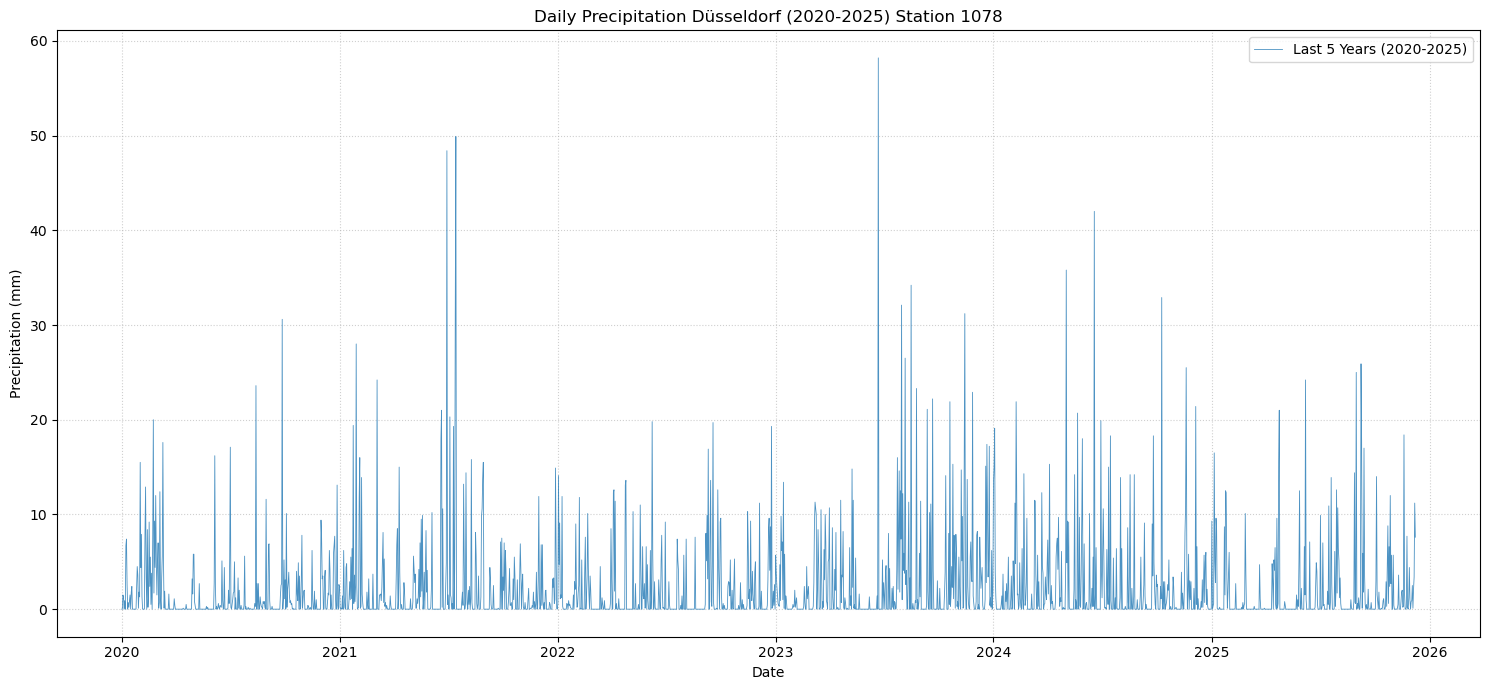

In [6]:
last_5_years = df[df.index >= pd.to_datetime("2020-01-01")]

# Plot the last 5 years separately
plt.figure(figsize=(15, 7))
plt.plot(last_5_years.index, last_5_years[value_col_name], 
         label='Last 5 Years (2020-2025)', 
         color='#1f77b4',  # Standard matplotlib blue
         linewidth=0.6,    # Thinner line for dense daily data
         alpha=0.8)  # Thicker line for the last 5 years

plt.title(f'Daily Precipitation Düsseldorf ({last_5_years.index[0].year}-{last_5_years.index[-1].year}) Station 1078')
plt.xlabel('Date')
plt.ylabel('Precipitation (mm)')

# Add a legend and grid
plt.legend(loc='upper right')
plt.grid(True, linestyle=':', alpha=0.6)

# Optional: Set Y-axis limit if outliers make the plot unreadable
# plt.ylim(0, 100) 

plt.tight_layout()